# 📚 Importing Important Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob as gb
import cv2
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


# 📥 Import Dataset from Kaggle

In [22]:
import kagglehub

path = kagglehub.dataset_download("gannayasser/arabic-alphabets-sign-language-dataset-arasl")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'arabic-alphabets-sign-language-dataset-arasl' dataset.
Path to dataset files: /kaggle/input/arabic-alphabets-sign-language-dataset-arasl


# 📊 Define the Path and Explore the Dataset (EDA)

In [23]:
path = '/kaggle/input/arabic-alphabets-sign-language-dataset-arasl/ArASL_Database_54K_Final/ArASL_Database_54K_Final'

code = {}
for i, folder in enumerate(sorted(os.listdir(path))):
    code[folder] = i

print("🔤 Number of Classes:", len(code))
print("\n📊 Dataset Distribution:")

for folder in sorted(os.listdir(path)):
    files = gb.glob(pathname=os.path.join(path, folder, '*.jpg'))
    print(f"📁 {folder}: {len(files)} images")

🔤 Number of Classes: 32

📊 Dataset Distribution:
📁 ain: 1735 images
📁 al: 1210 images
📁 aleff: 1270 images
📁 bb: 1347 images
📁 dal: 1244 images
📁 dha: 1378 images
📁 dhad: 1312 images
📁 fa: 1591 images
📁 gaaf: 1358 images
📁 ghain: 1606 images
📁 ha: 1251 images
📁 haa: 1152 images
📁 jeem: 1165 images
📁 kaaf: 1407 images
📁 khaa: 1234 images
📁 la: 1423 images
📁 laam: 1465 images
📁 meem: 1396 images
📁 nun: 1450 images
📁 ra: 1277 images
📁 saad: 1510 images
📁 seen: 1281 images
📁 sheen: 1144 images
📁 ta: 1461 images
📁 taa: 1442 images
📁 thaa: 1370 images
📁 thal: 1221 images
📁 toot: 1457 images
📁 waw: 1027 images
📁 ya: 1327 images
📁 yaa: 1203 images
📁 zay: 1004 images


# 🖼️ Display Random Samples of the Dataset

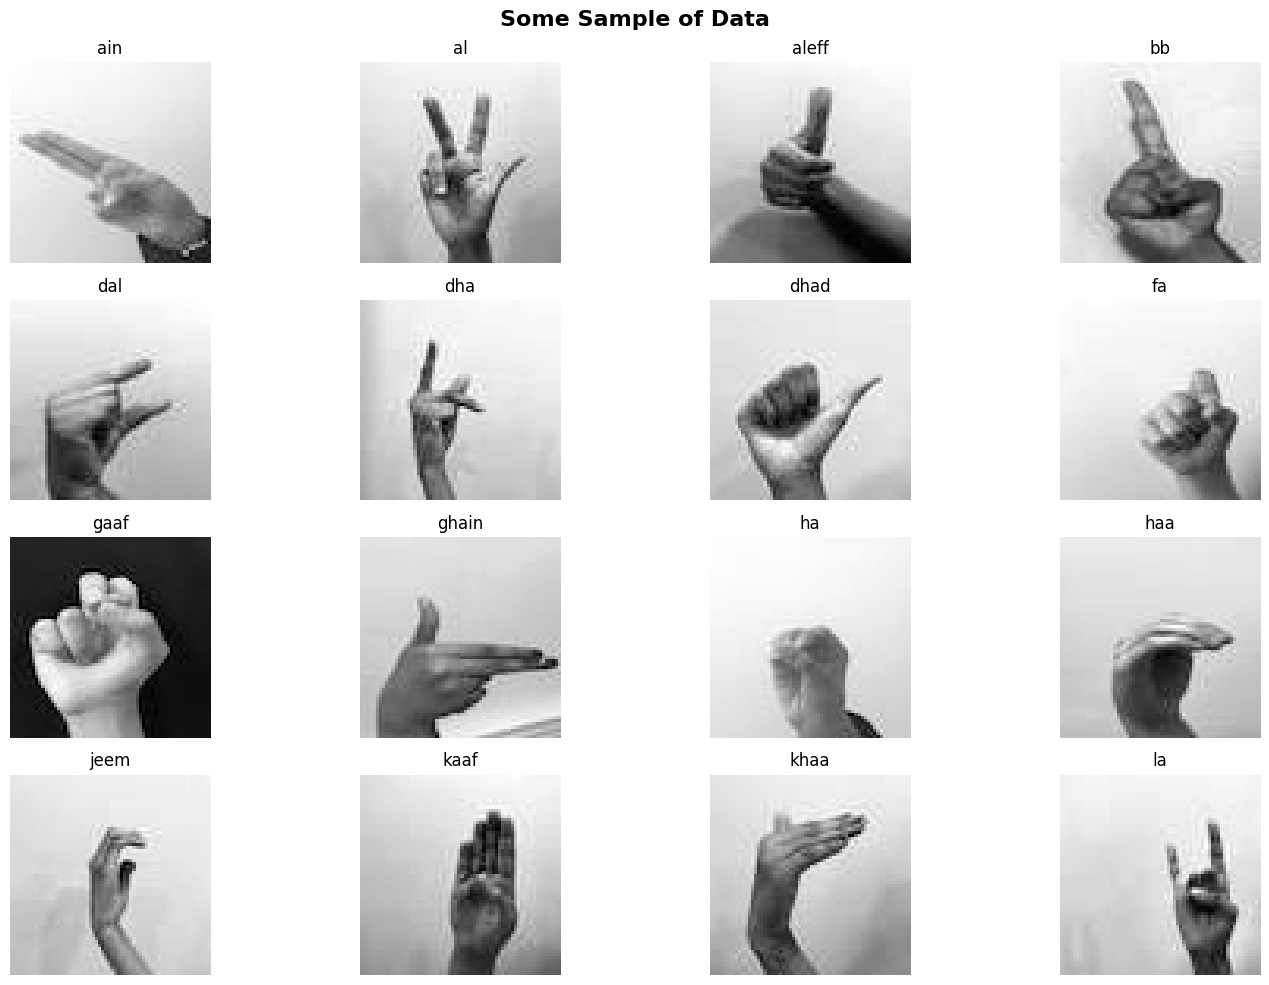

In [24]:
plt.figure(figsize=(15, 10))
sample_images = []
for folder in sorted(os.listdir(path)):
    files = gb.glob(pathname=os.path.join(path, folder, '*.jpg'))
    if len(files) > 0:
        sample_images.append((files[0], folder))


for n, (img_path, label) in enumerate(sample_images[:16]):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    plt.subplot(4, 4, n+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(label, fontsize=12)
plt.suptitle('Some Sample of Data' , fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 📏 Image Reading and Resizing

In [25]:
s = 64

X = []
y = []

print("⏳ Reading and resizing images...")
for folder in sorted(os.listdir(path)):
    files = gb.glob(pathname=os.path.join(path, folder, '*.jpg'))
    for file in files:
        img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img_resized = cv2.resize(img, (s, s))
            X.append(img_resized)
            y.append(code[folder])

print(f"✅ Total image : {len(X)}")

⏳ Reading and resizing images...
✅ Total image : 42718


# 🔄 Data Transformation

In [26]:
X = np.array(X).reshape(-1, s, s, 1) / 255.0  # Normalization بين 0 و 1
y = np.array(y)

print(f"📐 X Shape: {X.shape}")
print(f"📐 Y Shape: {y.shape}")

📐 X Shape: (42718, 64, 64, 1)
📐 Y Shape: (42718,)


# ✂️ Splitting

In [27]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\n🎓 Training:   {X_train.shape[0]} ")
print(f"🧪 Validation: {X_val.shape[0]} ")
print(f"🧪 Test:       {X_test.shape[0]} ")


🎓 Training:   34174 
🧪 Validation: 4272 
🧪 Test:       4272 


# 🧠 Build ANN Model


In [33]:
ann_model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=(s, s, 1)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(32, activation='softmax')
], name="ANN_Model")


In [34]:
ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("📋 ANN Summary:")
ann_model.summary()

📋 ANN Summary:


Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,016 (8.64 MB)

 Trainable params: 2,266,016 (8.64 MB)

 Non-trainable params: 0 (0.00 B)

# ⏳ Callback

In [35]:
ann_early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
ann_checkpoint = ModelCheckpoint("best_ann_model.keras", monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
ann_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001, verbose=1)

# 🚀 Training ANN Model

In [36]:
history_ann = ann_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[ann_early_stop, ann_checkpoint, ann_reduce_lr],
    verbose=1
)

Epoch 1/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0375 - loss: 3.5571
Epoch 1: val_accuracy improved from None to 0.06461, saving model to best_ann_model.keras

Epoch 1: finished saving model to best_ann_model.keras
534/534 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.0452 - loss: 3.4403 - val_accuracy: 0.0646 - val_loss: 3.2683 - learning_rate: 0.0010
Epoch 2/20
529/534 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0602 - loss: 3.3024
Epoch 2: val_accuracy improved from 0.06461 to 0.10604, saving model to best_ann_model.keras

Epoch 2: finished saving model to best_ann_model.keras
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0662 - loss: 3.2695 - val_accuracy: 0.1060 - val_loss: 3.0749 - learning_rate: 0.0010
Epoch 3/20
525/534 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0798 - loss: 3.1833
Epoch 3: val_accuracy improved from 0.10604 to 0.12430, saving model to best_ann_model.keras

Epoch 3: finished saving model to best_ann_model.keras
534/534 ━━━━━━━━

# 📊 ANN Evaluation

🔴 ANN Test Loss: 2.9998
🔴 ANN Test Accuracy: 13.39%

134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
📋 ANN Classification Report:
              precision    recall  f1-score   support

         ain       0.24      0.25      0.25       173
          al       0.00      0.00      0.00       121
       aleff       1.00      0.13      0.24       127
          bb       0.52      0.09      0.15       135
         dal       0.45      0.07      0.12       125
         dha       0.92      0.09      0.16       138
        dhad       1.00      0.07      0.13       131
          fa       1.00      0.05      0.10       159
        gaaf       0.60      0.04      0.08       136
       ghain       1.00      0.03      0.06       160
          ha       1.00      0.02      0.03       125
         haa       0.50      0.03      0.05       115
        jeem       1.00      0.03      0.05       117
        kaaf       0.91      0.07      0.13       141
        khaa       0.00      0.00      0.00       124
          la

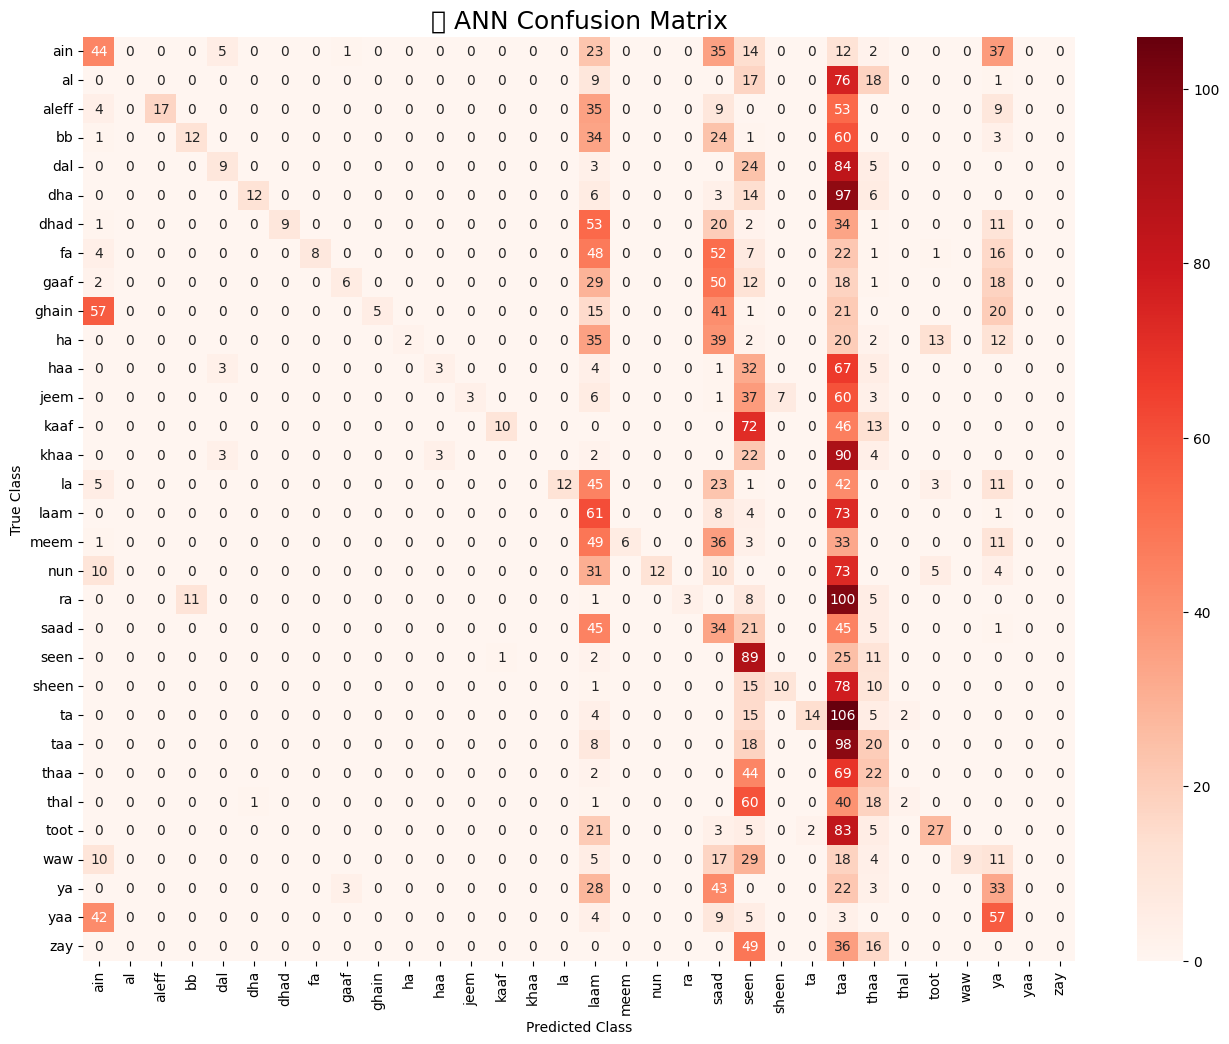

In [37]:
ann_model.load_weights("best_ann_model.keras")

test_loss_ann, test_acc_ann = ann_model.evaluate(X_test, y_test, verbose=0)
print(f"🔴 ANN Test Loss: {test_loss_ann:.4f}")
print(f"🔴 ANN Test Accuracy: {test_acc_ann*100:.2f}%\n")

y_pred_ann = np.argmax(ann_model.predict(X_test), axis=1)
class_names = list(code.keys())
print("📋 ANN Classification Report:")
print(classification_report(y_test, y_pred_ann, target_names=class_names))

cm_ann = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_ann, annot=True, cmap='Reds', fmt='g',
            xticklabels=class_names, yticklabels=class_names)
plt.title('🔴 ANN Confusion Matrix', fontsize=18)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

# 🧠 Build CNN Model

In [28]:
cnn_model = keras.models.Sequential([
    keras.layers.Conv2D(200, kernel_size=(3,3), activation='relu', input_shape=(s, s, 1)),
    keras.layers.Conv2D(150, kernel_size=(3,3), activation='relu'),
    keras.layers.MaxPool2D(4,4),

    keras.layers.Conv2D(120, kernel_size=(3,3), activation='relu'),
    keras.layers.Conv2D(80, kernel_size=(3,3), activation='relu'),
    keras.layers.Conv2D(50, kernel_size=(3,3), activation='relu'),
    keras.layers.MaxPool2D(4,4),

    keras.layers.Flatten(),
    keras.layers.Dense(120, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(32, activation='softmax')
], name="CNN_Model")



In [29]:
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("📋 CNN Summary:")
cnn_model.summary()

📋 CNN Summary:


Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 62, 62, 200)    │         2,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 60, 60, 150)    │       270,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 150)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 120)    │       162,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 80)     │        86,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 9, 9, 50)       │        36,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 120)            │        24,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        12,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         1,632 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 599,702 (2.29 MB)

 Trainable params: 599,702 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

#⏳ Callback

In [30]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_cnn_model.keras", monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001, verbose=1)

#🚀 Training ANN Model

In [31]:
history_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=24,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/24
534/534 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.0366 - loss: 3.4580
Epoch 1: val_accuracy improved from None to 0.18235, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
534/534 ━━━━━━━━━━━━━━━━━━━━ 55s 94ms/step - accuracy: 0.0528 - loss: 3.3956 - val_accuracy: 0.1824 - val_loss: 2.7262 - learning_rate: 0.0010
Epoch 2/24
534/534 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.2784 - loss: 2.2920
Epoch 2: val_accuracy improved from 0.18235 to 0.71184, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
534/534 ━━━━━━━━━━━━━━━━━━━━ 46s 86ms/step - accuracy: 0.3942 - loss: 1.8485 - val_accuracy: 0.7118 - val_loss: 0.8369 - learning_rate: 0.0010
Epoch 3/24
534/534 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6509 - loss: 0.9867
Epoch 3: val_accuracy improved from 0.71184 to 0.85042, saving model to best_cnn_model.keras

Epoch 3: finished saving model to best_cnn_model.keras
534/534 ━

In [32]:
from google.colab import files
files.download('/content/best_cnn_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#📊 CNN Evaltuion

🟢 CNN Test Loss: 0.0457
🟢 CNN Test Accuracy: 98.81%

134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
📋 CNN Classification Report:
              precision    recall  f1-score   support

         ain       1.00      1.00      1.00       173
          al       1.00      1.00      1.00       121
       aleff       0.98      0.99      0.98       127
          bb       0.98      0.98      0.98       135
         dal       1.00      1.00      1.00       125
         dha       0.96      0.94      0.95       138
        dhad       1.00      1.00      1.00       131
          fa       0.98      0.99      0.98       159
        gaaf       0.97      0.98      0.97       136
       ghain       0.99      0.99      0.99       160
          ha       0.98      0.98      0.98       125
         haa       0.99      0.98      0.99       115
        jeem       0.96      0.97      0.97       117
        kaaf       0.99      1.00      0.99       141
        khaa       1.00      0.98      0.99       124
          l

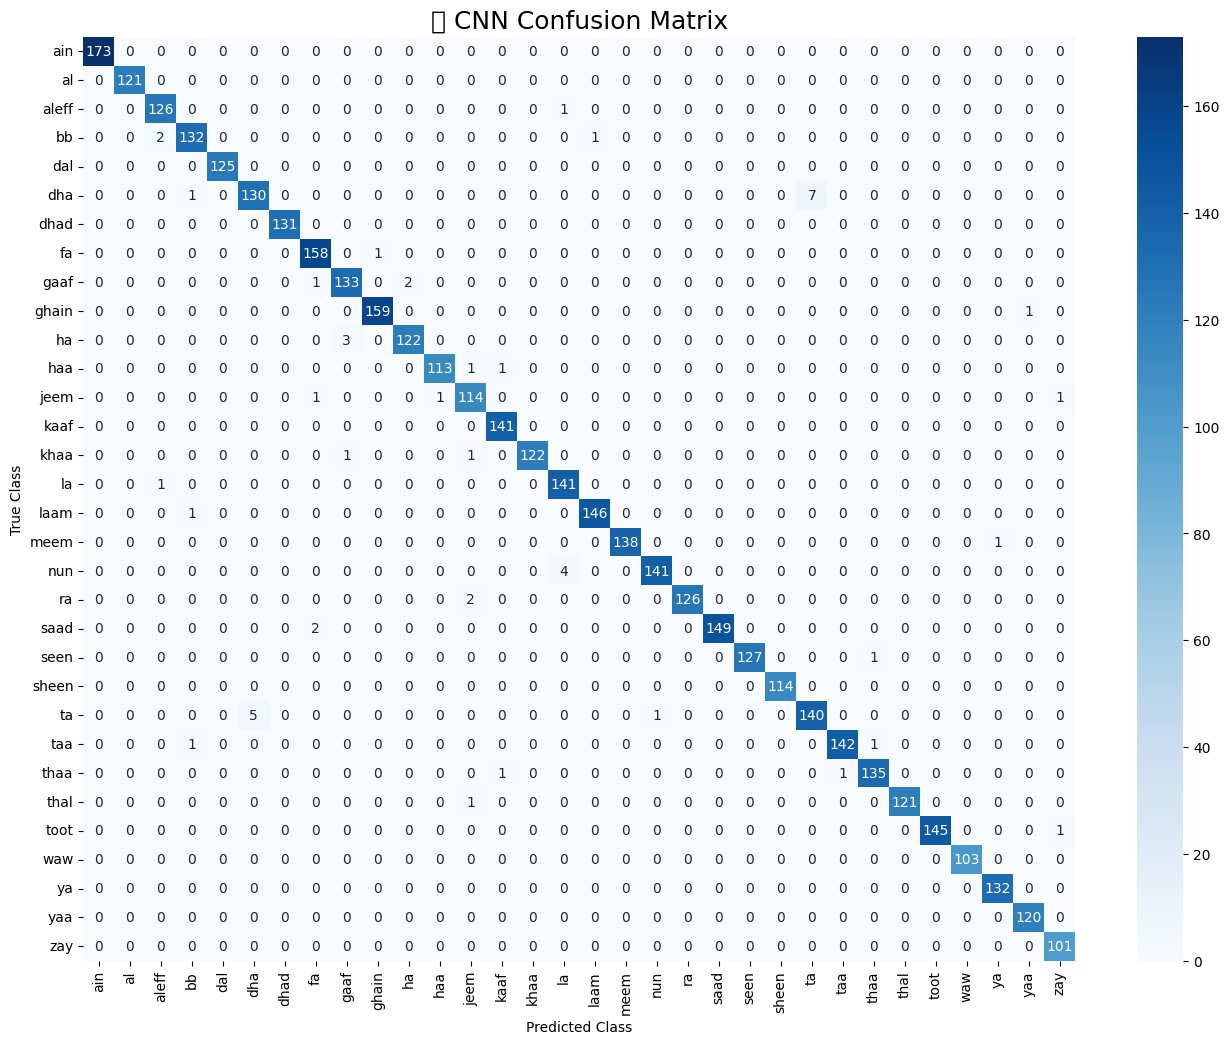

In [38]:
cnn_model.load_weights("best_cnn_model.keras")

test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"🟢 CNN Test Loss: {test_loss_cnn:.4f}")
print(f"🟢 CNN Test Accuracy: {test_acc_cnn*100:.2f}%\n")


y_pred_cnn = np.argmax(cnn_model.predict(X_test), axis=1)

# Classification Report
class_names = list(code.keys())
print("📋 CNN Classification Report:")
print(classification_report(y_test, y_pred_cnn, target_names=class_names))

# Confusion Matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_cnn, annot=True, cmap='Blues', fmt='g',
            xticklabels=class_names, yticklabels=class_names)
plt.title('🟢 CNN Confusion Matrix', fontsize=18)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

# 📈 Plotting

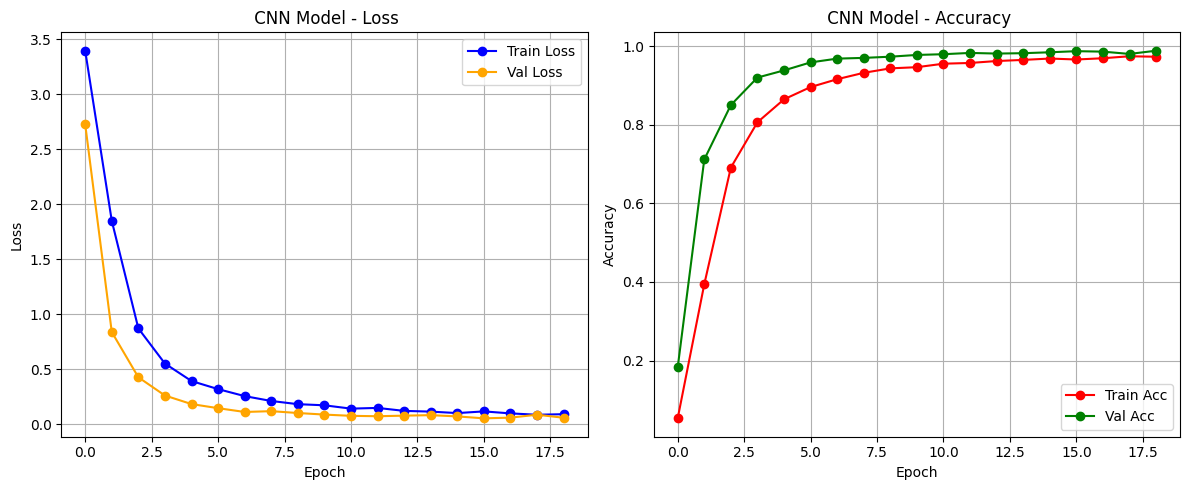

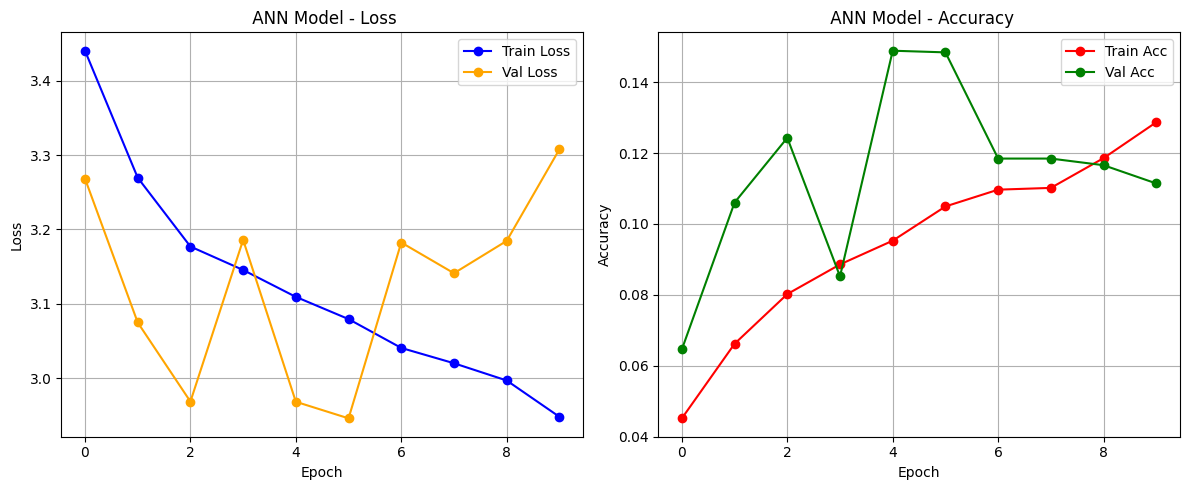

In [39]:
def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss', marker='o', color='blue')
    plt.plot(history.history['val_loss'], label='Val Loss', marker='o', color='orange')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc', marker='o', color='red')
    plt.plot(history.history['val_accuracy'], label='Val Acc', marker='o', color='green')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_cnn, " CNN Model")
plot_history(history_ann, " ANN Model")

# 🧪 Test Set

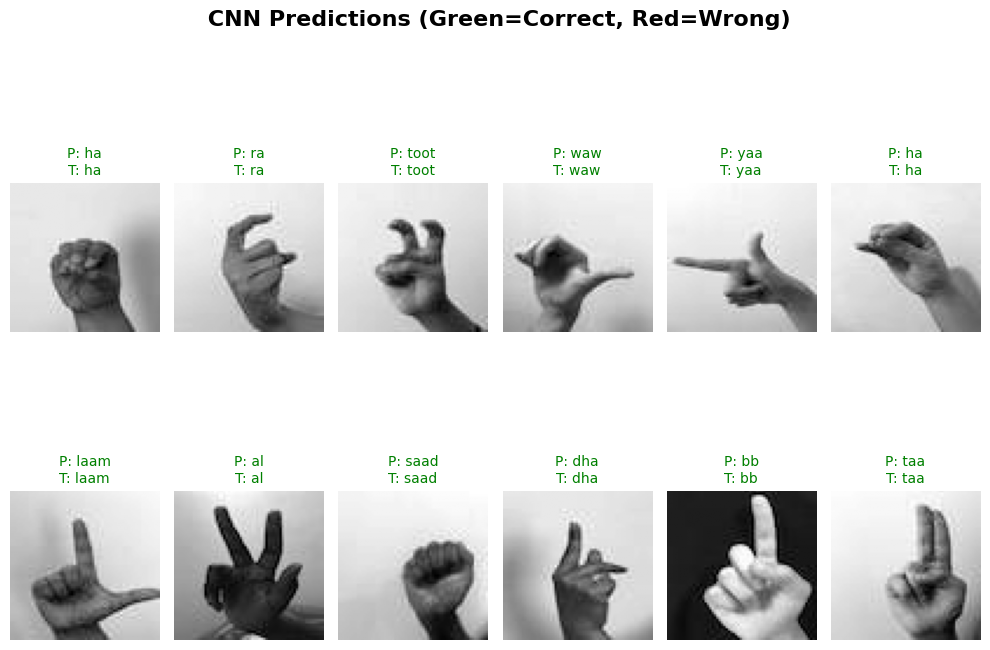

In [40]:
def getcode(n):
    for x, y in code.items():
        if n == y:
            return x
    return "Unknown"

plt.figure(figsize=(10, 8))
for n, i in enumerate(list(np.random.randint(0, len(X_test), 12))):
    plt.subplot(2,6, n+1)
    plt.imshow(X_test[i].reshape(s, s), cmap='gray')
    plt.axis('off')

    pred = y_pred_cnn[i]
    true = y_test[i]
    pred_label = getcode(pred)
    true_label = getcode(true)

    color = 'green' if pred == true else 'red'
    plt.title(f"P: {pred_label}\nT: {true_label}", color=color, fontsize=10)

plt.suptitle(" CNN Predictions (Green=Correct, Red=Wrong)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 🎁 Boooouns (+_+)

# 🚀 Transfer Learning with MobileNetV2

In [ ]:
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb = np.repeat(X_val, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

# 🧠 Build Transfer Learning Model

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(s, s, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False
tl_model = keras.Sequential([
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(32, activation='softmax')
], name="Transfer_Learning_Model")

In [ ]:
tl_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

In [ ]:
print("📋 Transfer Learning Model Summary:")
tl_model.summary()


📋 Transfer Learning Model Summary:


Model: "Transfer_Learning_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         8,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,144 (9.90 MB)

 Trainable params: 336,160 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

#⏳ Callback

In [ ]:
tl_checkpoint = ModelCheckpoint("best_tl_model.keras", monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)


# 🚀 Transfer Learning Training

In [ ]:
history_tl = tl_model.fit(
    X_train_rgb, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_rgb, y_val),
    callbacks=[early_stop, tl_checkpoint, reduce_lr]
)

In [ ]:
tl_model.load_weights("best_tl_model.keras")

# 📊 Transfer Learning Evaluation

In [ ]:
tl_loss, tl_acc = tl_model.evaluate(X_test_rgb, y_test, verbose=0)
print(f"\n🚀 Transfer Learning Test Accuracy: {tl_acc*100:.2f}%")